# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [2]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches


## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [3]:
# ==============================================================================
# 2. CONFIGURATION & PARAMETERS
# ============================================================================== 

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137          # Coronal slice index to extract
ROI_CROP = (220, 140)        # (row_start, col_start) for working region cropping

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.70  # Initial mask: percentage of max intensity

# Radiomic parameters
FEATURE_CLASS = "firstorder"  # Only firstorder features are supported in current pipeline
FEATURE_NAME = "Median"      # Example values: Median, Mean, Entropy, Energy
FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

K_VALUE = 10                 # Acceptance limits: mean ± k*std
NUM_ITERATIONS = 20          # Number of region-growing iterations

print(f" Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - K-value (acceptance bounds): {K_VALUE}")
print(f"  - Iterations: {NUM_ITERATIONS}")

 Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Radiomic feature: firstorder.Median
  - K-value (acceptance bounds): 10
  - Iterations: 20


## Stage 1: Data Loading & Preparation

In [4]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


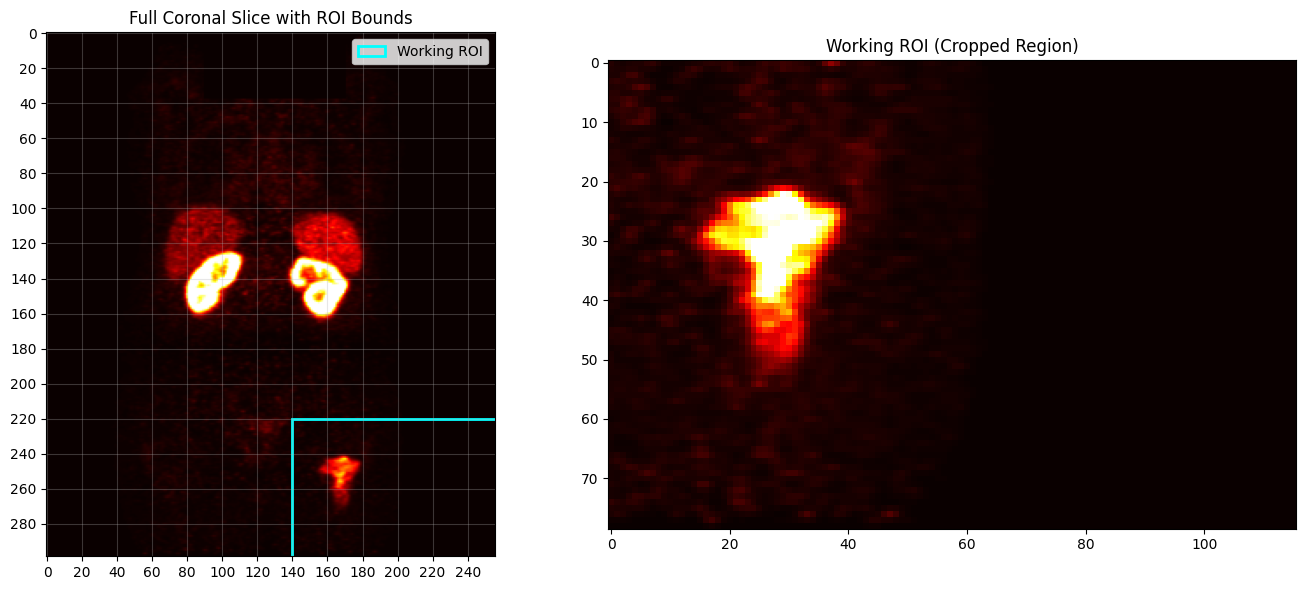

In [5]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE

# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP, en objeto numpy

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 70% of max = 13612.28
  - Mask size: 53 voxels


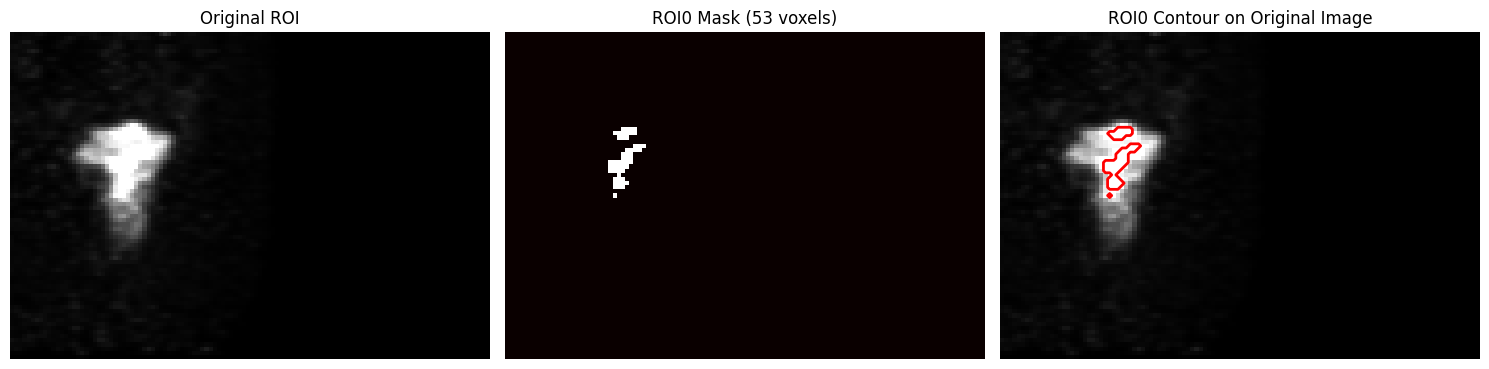

In [6]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

In [7]:
# Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()  # Crear una instancia del extractor de PyRadiomics con la configuración por defecto
extractor.disableAllFeatures()  # Desactivar todas las características para evitar cálculos innecesarios
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})  # Habilitar únicamente la característica especificada (ej. firstorder: Median)

print(f"✓ PyRadiomics extractor initialized") 
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")  
print(f"  - Voxel-based extraction enabled") 

✓ PyRadiomics extractor initialized
  - Feature: firstorder.Median
  - Voxel-based extraction enabled


In [8]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key): #recibe imagen y debuelve un numpy
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

✓ Reference distribution computed from ROI0
  - Feature: original_firstorder_Median
  - Number of voxels: 53
  - Mean: 15442.4533
  - Std: 938.8707
  - Acceptance bounds (k=10):
    • Lower limit: 6053.7459
    • Upper limit: 24831.1607


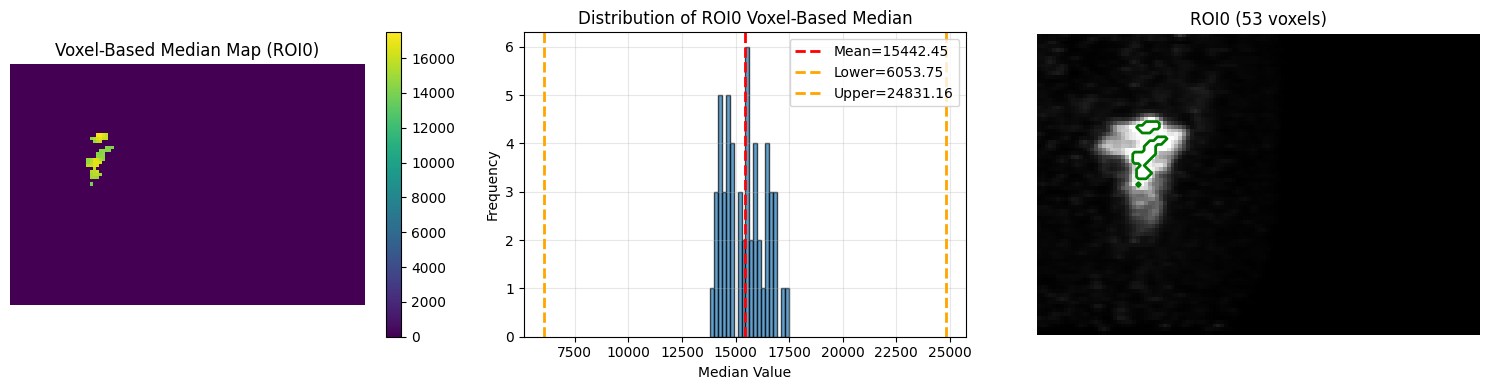

In [9]:
# Extract voxel-based radiomic map for ROI0

# Convert to 3D format required by PyRadiomics
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)  # Convierte la imagen 2D en un volumen 3D (1×H×W) de tipo float32 requerido por PyRadiomics.
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)  # Convierte la máscara binaria 2D en un volumen 3D (1×H×W) de tipo uint8.

sitk_img = sitk.GetImageFromArray(img_3d)  # Convierte el volumen de imagen de NumPy a un objeto SimpleITK.
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)  # Convierte el volumen de la máscara a un objeto SimpleITK.

# Extract voxel-based radiomic map
result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)  # Calcula el mapa radiomico voxel-based dentro del bounding box definido por la máscara.

# Reconstruct full map and extract ROI0 voxel values
voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)  # Reconstruye el mapa radiomico al tamaño original de la ROI usando la información del bounding box.
vals_roi0 = voxel_map_roi0[mask0]  # Conserva únicamente los valores radiomicos correspondientes a los voxeles de la máscara ROI0. Esun numpy

# Compute statistics
mean_ref = vals_roi0.mean()  # Calcula la media de los valores radiomicos dentro de ROI0. es la media de la característica radiomica (ej. Median) de todos los voxeles que pertenecen a la ROI0.
std_ref = vals_roi0.std()  # Calcula la desviación estándar de los valores radiomicos dentro de ROI0.

# Define acceptance limits (fixed throughout all iterations)
lower_limit = mean_ref - K_VALUE * std_ref  # Define el límite inferior del criterio de aceptación.
upper_limit = mean_ref + K_VALUE * std_ref  # Define el límite superior del criterio de aceptación.


print(f"✓ Reference distribution computed from ROI0")
print(f"  - Feature: {FEATURE_KEY}")
print(f"  - Number of voxels: {len(vals_roi0)}")
print(f"  - Mean: {mean_ref:.4f}")
print(f"  - Std: {std_ref:.4f}")
print(f"  - Acceptance bounds (k={K_VALUE}):")
print(f"    • Lower limit: {lower_limit:.4f}")
print(f"    • Upper limit: {upper_limit:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(voxel_map_roi0, cmap="viridis")
axes[0].set_title(f"Voxel-Based {FEATURE_NAME} Map (ROI0)")
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])
axes[0].axis('off')

axes[1].hist(vals_roi0, bins=20, edgecolor='k', alpha=0.7)
axes[1].axvline(mean_ref, color='r', linestyle='--', linewidth=2, label=f'Mean={mean_ref:.2f}')
axes[1].axvline(lower_limit, color='orange', linestyle='--', linewidth=2, label=f'Lower={lower_limit:.2f}')
axes[1].axvline(upper_limit, color='orange', linestyle='--', linewidth=2, label=f'Upper={upper_limit:.2f}')
axes[1].set_xlabel(f"{FEATURE_NAME} Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Distribution of ROI0 Voxel-Based {FEATURE_NAME}")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='g', linewidths=2)
axes[2].set_title(f"ROI0 ({mask0.sum()} voxels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 5: Iterative Region Growing

In [10]:


roi_current = mask0.copy()  # Crea una copia de la máscara inicial ROI0 para usarla como ROI actual.
results = []  # Inicializa una lista vacía donde se guardarán los resultados numéricos de cada iteración.
history = []  # Inicializa una lista vacía donde se guardará información detallada de cada iteración.

print(f"Starting iterative region growing ({NUM_ITERATIONS} iterations)...\n")  # Imprime un mensaje indicando cuántas iteraciones se van a ejecutar.

for iteration in range(1, NUM_ITERATIONS + 1):  # Inicia el ciclo iterativo desde 1 hasta NUM_ITERATIONS.
    
    # Paso 1: generar voxeles candidatos mediante dilatación de la ROI actual.
    roi_dilated = binary_dilation(roi_current)  # Dilata la ROI actual para expandirla un voxel alrededor de sus bordes.
    corona = roi_dilated & (~roi_current)  # Obtiene solo los nuevos voxeles agregados por la dilatación, excluyendo la ROI original.
    
    # Step 2:calcular el mapa radiomico voxel-based sobre la ROI dilatada.
    mask_3d = roi_dilated.astype(np.uint8)[np.newaxis, :, :]  # Convierte la máscara dilatada a uint8 y le agrega una dimensión extra para hacerla 3D.
    sitk_mask = sitk.GetImageFromArray(mask_3d)  # Convierte la máscara 3D de NumPy a una imagen SimpleITK.
    
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)  # Ejecuta PyRadiomics para extraer la característica voxel-based dentro de la máscara dilatada.
    
    # Step 3: Reconstruct full-size map from PyRadiomics bounding box
    full_map, _ = reconstruct_voxel_map(result, roi_img.shape, FEATURE_KEY)  # Reconstruye el mapa radiomico al tamaño original de la ROI.
    
    # Paso 4: extraer los valores radiomicos correspondientes a los voxeles de la corona.
    corona_values = full_map[corona]  # Obtiene los valores del mapa radiomico únicamente en los voxeles candidatos de la corona.
    
    # Step 5: Classify voxels (accept if within statistical bounds)
    accepted = (  # Crea un arreglo booleano que indica qué voxeles de la corona son aceptados.
        (corona_values >= lower_limit) &  # Verifica que cada valor radiomico sea mayor o igual al límite inferior.
        (corona_values <= upper_limit)  # Verifica que cada valor radiomico sea menor o igual al límite superior.
    ) 
    
    # Step 6: Create mask of accepted voxels 
    mask_accepted = np.zeros_like(roi_current, dtype=bool)  # Crea una máscara booleana vacía con el mismo tamaño que la ROI actual.
    mask_accepted[corona] = accepted  # Coloca los valores aceptados en las posiciones correspondientes a la corona.
    
    # Step 7: Update ROI with accepted voxels  
    roi_new = roi_current | mask_accepted  # Une la ROI actual con la máscara de voxeles aceptados para formar la nueva ROI.
    
    # Step 8: Store results  
    n_accepted = accepted.sum()  # Cuenta cuántos voxeles de la corona fueron aceptados.
    n_rejected = (~accepted).sum()  # Cuenta cuántos voxeles de la corona fueron rechazados.
    
    results.append({  # Agrega un diccionario con el resumen numérico de la iteración a la lista results.
        "Iteration": iteration,  # Guarda el número de iteración.
        "Current ROI Size": roi_current.sum(),  # Guarda el tamaño de la ROI antes de agregar nuevos voxeles.
        "Corona Size": corona.sum(),  # Guarda el número total de voxeles candidatos en la corona.
        "Accepted": n_accepted,  # Guarda el número de voxeles aceptados.
        "Rejected": n_rejected,  # Guarda el número de voxeles rechazados.
        "New ROI Size": roi_new.sum()  # Guarda el tamaño de la nueva ROI después de agregar los voxeles aceptados.
    })  # Termina el diccionario de resultados de la iteración.
    
    history.append({  # Agrega un diccionario con datos detallados de la iteración a la lista history.
        "iteration": iteration,  # Guarda el número de iteración.
        "roi_current": roi_current.copy(),  # Guarda una copia de la ROI actual antes de actualizarla.
        "roi_dilated": roi_dilated.copy(),  # Guarda una copia de la ROI dilatada.
        "corona": corona.copy(),  # Guarda una copia de la corona de voxeles candidatos.
        "mask_accepted": mask_accepted.copy(),  # Guarda una copia de la máscara de voxeles aceptados.
        "corona_values": corona_values.copy(),  # Guarda una copia de los valores radiomicos de la corona.
        "voxel_map": full_map.copy()  # Guarda una copia del mapa radiomico completo.
    })  # Termina el diccionario de historial de la iteración.
    
    # Print progress  # Imprimir el progreso de la iteración actual.
    size_increase = roi_new.sum() - roi_current.sum()  # Calcula cuántos voxeles aumentó la ROI en esta iteración.
    print(f"Iter {iteration:2d}: ROI {roi_current.sum():4d} → {roi_new.sum():4d} "  # Imprime el número de iteración y el cambio de tamaño de la ROI.
          f"| Corona: {corona.sum():4d} | Acc: {n_accepted:4d} | Rej: {n_rejected:4d} | "  # Imprime el tamaño de la corona, aceptados y rechazados.
          f"Growth: {size_increase:+4d}")  # Imprime el crecimiento neto de la ROI en esta iteración.
    
    # Update for next iteration  # Actualizar la ROI para la siguiente iteración.
    roi_current = roi_new  # La nueva ROI se convierte en la ROI actual para la próxima iteración.

print("\n✓ Iterative region growing completed!")  # Imprime un mensaje indicando que el crecimiento iterativo terminó.

# Create results DataFrame  # Crear una tabla de resultados.
df_results = pd.DataFrame(results)  # Convierte la lista de resultados en un DataFrame de pandas.
print("\nResults Summary:")  # Imprime un título para el resumen de resultados.
print(df_results)  # Muestra la tabla con los resultados de todas las iteraciones.

Starting iterative region growing (20 iterations)...

Iter  1: ROI   53 →  104 | Corona:   51 | Acc:   51 | Rej:    0 | Growth:  +51
Iter  2: ROI  104 →  151 | Corona:   48 | Acc:   47 | Rej:    1 | Growth:  +47
Iter  3: ROI  151 →  184 | Corona:   49 | Acc:   33 | Rej:   16 | Growth:  +33
Iter  4: ROI  184 →  208 | Corona:   51 | Acc:   24 | Rej:   27 | Growth:  +24
Iter  5: ROI  208 →  233 | Corona:   54 | Acc:   25 | Rej:   29 | Growth:  +25
Iter  6: ROI  233 →  252 | Corona:   57 | Acc:   19 | Rej:   38 | Growth:  +19
Iter  7: ROI  252 →  264 | Corona:   61 | Acc:   12 | Rej:   49 | Growth:  +12
Iter  8: ROI  264 →  271 | Corona:   64 | Acc:    7 | Rej:   57 | Growth:   +7
Iter  9: ROI  271 →  275 | Corona:   65 | Acc:    4 | Rej:   61 | Growth:   +4
Iter 10: ROI  275 →  279 | Corona:   65 | Acc:    4 | Rej:   61 | Growth:   +4
Iter 11: ROI  279 →  282 | Corona:   65 | Acc:    3 | Rej:   62 | Growth:   +3
Iter 12: ROI  282 →  282 | Corona:   65 | Acc:    0 | Rej:   65 | Growth:   +

## Stage 6: Results & Visualizations

In [11]:
# Results summary table
print("\n" + "="*80)
print("ITERATIVE REGION GROWING RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Summary statistics
roi_final = history[-1]["roi_current"] | history[-1]["mask_accepted"]
total_growth = roi_final.sum() - mask0.sum()
percent_growth = (total_growth / mask0.sum()) * 100

print(f"\nFinal Summary:")
print(f"  - Initial ROI0 size: {mask0.sum()} voxels")
print(f"  - Final ROI size: {roi_final.sum()} voxels")
print(f"  - Total voxels added: {total_growth} voxels ({percent_growth:.1f}% growth)")
print(f"  - Total iterations: {NUM_ITERATIONS}")
print(f"  - Reference bounds: [{lower_limit:.4f}, {upper_limit:.4f}]")


ITERATIVE REGION GROWING RESULTS
 Iteration  Current ROI Size  Corona Size  Accepted  Rejected  New ROI Size
         1                53           51        51         0           104
         2               104           48        47         1           151
         3               151           49        33        16           184
         4               184           51        24        27           208
         5               208           54        25        29           233
         6               233           57        19        38           252
         7               252           61        12        49           264
         8               264           64         7        57           271
         9               271           65         4        61           275
        10               275           65         4        61           279
        11               279           65         3        62           282
        12               282           65         0   

C:\Users\oscar\AppData\Local\Temp\ipykernel_4600\9213125.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
C:\Users\oscar\AppData\Local\Temp\ipykernel_4600\9213125.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')


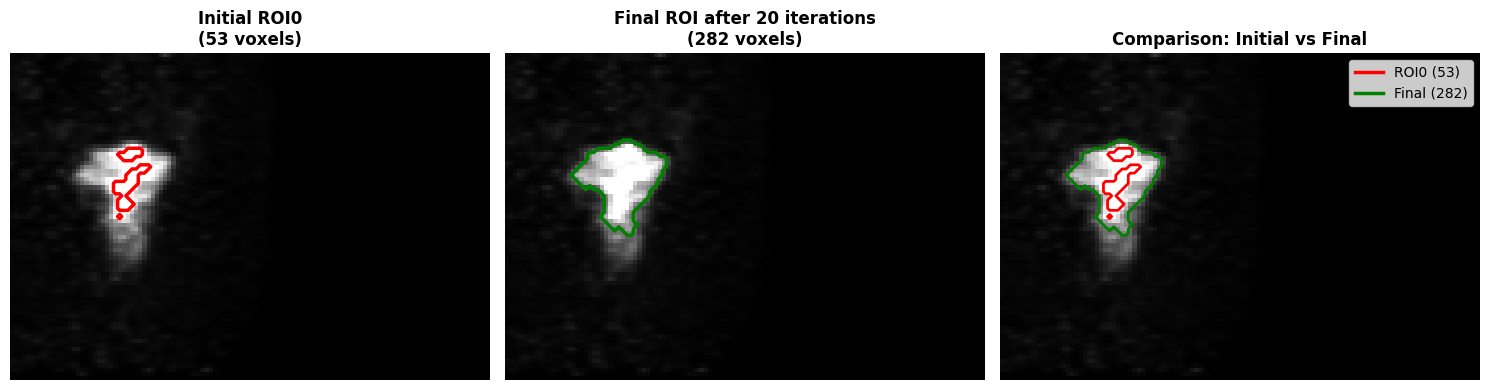

In [12]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {NUM_ITERATIONS} iterations\n({roi_final.sum()} voxels)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: Comparison with overlays
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='r', lw=2.5),
    Line2D([0], [0], color='g', lw=2.5)
]
axes[2].legend(custom_lines, [f'ROI0 ({mask0.sum()})', f'Final ({roi_final.sum()})'], 
               loc='upper right', fontsize=10)
axes[2].set_title("Comparison: Initial vs Final", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_4600\2916683759.py:9: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
C:\Users\oscar\AppData\Local\Temp\ipykernel_4600\2916683759.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
C:\Users\oscar\AppData\Local\Temp\ipykernel_4600\2916683759.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc='upper right')


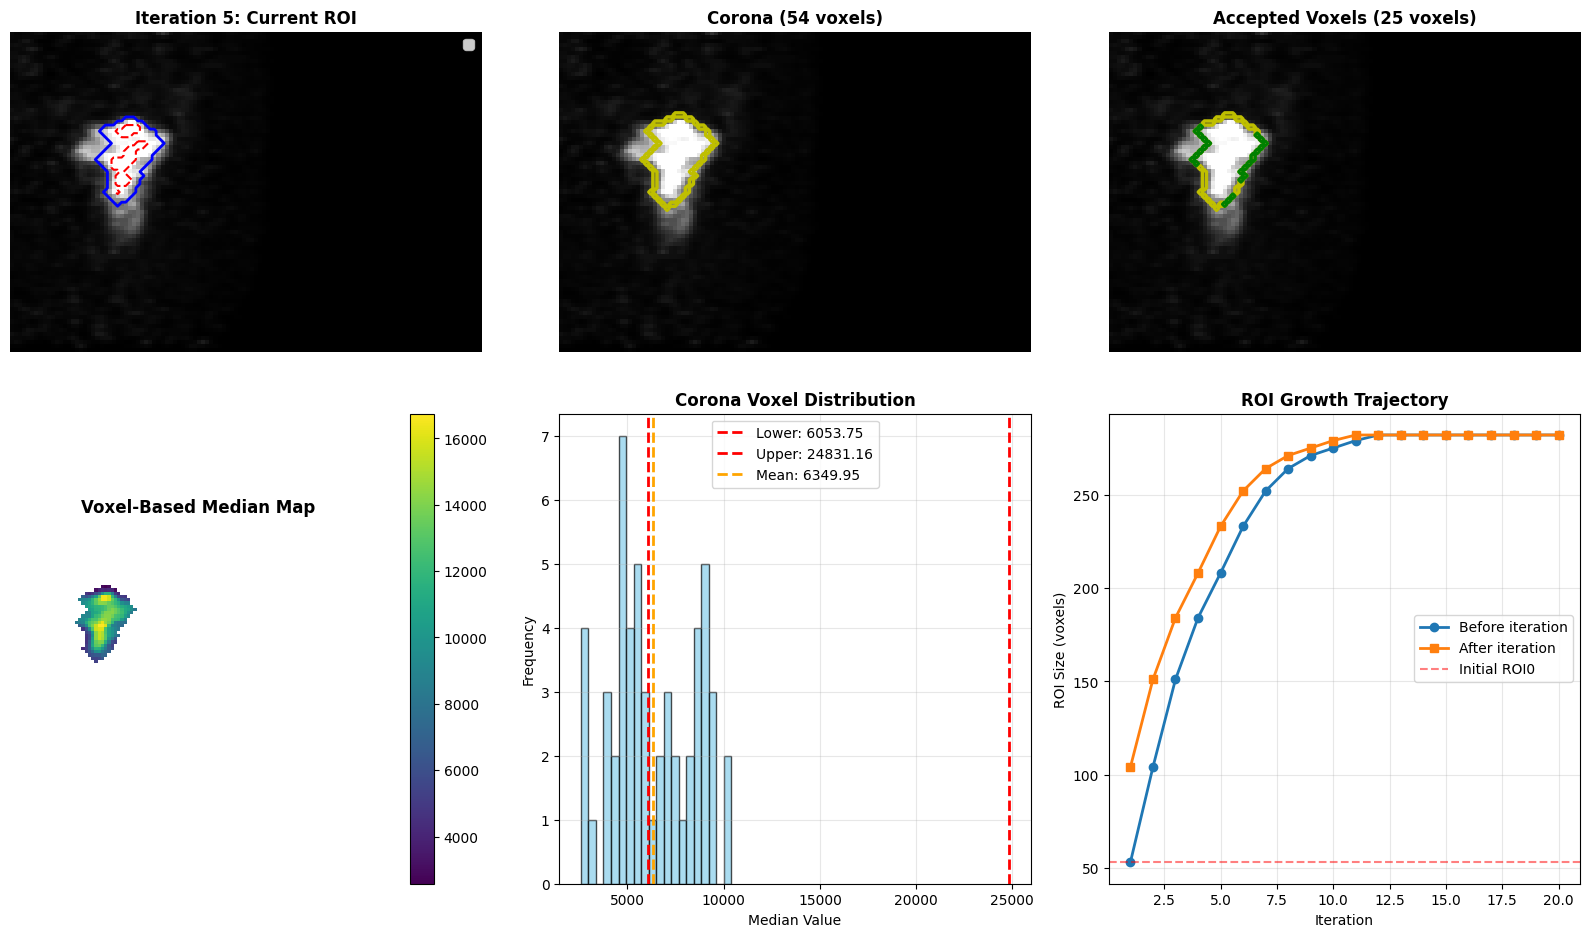

In [13]:
# Detailed visualization of a specific iteration (example: iteration 5)
iter_to_show = min(5, NUM_ITERATIONS)  # Show iteration 5, or last if fewer iterations
data_iter = history[iter_to_show - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Iteration details
axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
axes[0, 0].set_title(f"Iteration {iter_to_show}: Current ROI", fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].axis('off')

axes[0, 1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 1].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 1].set_title(f"Corona ({data_iter['corona'].sum()} voxels)", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 2].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 2].contour(data_iter["mask_accepted"], colors='g', linewidths=2.5)
axes[0, 2].set_title(f"Accepted Voxels ({data_iter['mask_accepted'].sum()} voxels)", fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Radiomic map and statistics
voxel_map = data_iter["voxel_map"]
voxel_map_masked = np.copy(voxel_map)
voxel_map_masked[voxel_map == 0] = np.nan

im = axes[1, 0].imshow(voxel_map_masked, cmap="viridis")
axes[1, 0].set_title("Voxel-Based Median Map", fontweight='bold')
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].axis('off')

corona_vals = data_iter["corona_values"]
axes[1, 1].hist(corona_vals[corona_vals > 0], bins=20, edgecolor='k', alpha=0.7, color='skyblue')
axes[1, 1].axvline(lower_limit, color='r', linestyle='--', linewidth=2, label=f'Lower: {lower_limit:.2f}')
axes[1, 1].axvline(upper_limit, color='r', linestyle='--', linewidth=2, label=f'Upper: {upper_limit:.2f}')
axes[1, 1].axvline(corona_vals[corona_vals > 0].mean(), color='orange', linestyle='--', 
                   linewidth=2, label=f'Mean: {corona_vals[corona_vals > 0].mean():.2f}')
axes[1, 1].set_xlabel("Median Value")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Corona Voxel Distribution", fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Growth trajectory
iter_range = [r["Iteration"] for r in results]
roi_sizes = [r["Current ROI Size"] for r in results]
new_sizes = [r["New ROI Size"] for r in results]

axes[1, 2].plot(iter_range, roi_sizes, 'o-', linewidth=2, markersize=6, label='Before iteration')
axes[1, 2].plot(iter_range, new_sizes, 's-', linewidth=2, markersize=6, label='After iteration')
axes[1, 2].axhline(mask0.sum(), color='r', linestyle='--', alpha=0.5, label='Initial ROI0')
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].set_ylabel("ROI Size (voxels)")
axes[1, 2].set_title("ROI Growth Trajectory", fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()